<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Restaurant_Orders_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d haseebindata/restaurant-orders

# Unziping the downloaded file
!unzip restaurant-orders.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/haseebindata/restaurant-orders
License(s): apache-2.0
  0% 0.00/11.7k [00:00<?, ?B/s]
100% 11.7k/11.7k [00:00<00:00, 37.1MB/s]
Archive:  restaurant-orders.zip
  inflating: restaurant_orders.csv   


In [6]:
df = pd.read_csv('restaurant_orders.csv')
df.head(11)

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,16.52,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17.27,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3.37,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2.20,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12.23,Cash,2025-03-15 14:25:56
5,1587,Matthew Miles,Brownie,Dessert,5,7.39,Credit Card,2025-04-12 05:49:18
6,2834,Catherine Thompson,Soup,Starter,3,8.31,Credit Card,2025-06-20 18:19:56
7,4514,Nathan Holland,Soup,Starter,4,2.28,Cash,2025-05-30 09:24:15
8,3946,Anthony Sherman,Pasta,Main,1,13.05,Credit Card,2025-06-03 01:41:32
9,3174,Carolyn Roberts,Cake,Dessert,4,19.48,Cash,2025-07-18 00:59:40


In [7]:
df.tail(11)

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
489,6244,Jason Russell,Burger,Main,1,5.86,Debit Card,2025-06-25 18:16:54
490,2902,Catherine Martinez,Brownie,Dessert,4,20.26,Credit Card,2025-07-03 20:17:22
491,8786,Thomas Huynh,Ice Cream,Dessert,2,2.27,Debit Card,2025-06-15 17:21:24
492,2814,Susan Browning,Pizza,Main,1,8.50,Debit Card,2025-01-10 23:10:29
493,5227,James Butler,Soup,Starter,4,13.64,Online Payment,2025-02-12 18:13:14
494,6096,Joseph Hamilton,Brownie,Dessert,1,2.59,Online Payment,2025-07-09 08:52:16
495,6323,Alyssa Anthony,Pizza,Main,1,21.31,Cash,2025-01-15 19:21:02
496,9836,Jerry Pineda,Soup,Starter,3,15.99,Debit Card,2025-07-15 15:00:19
497,1202,Brandy Smith,Pasta,Main,2,8.54,Credit Card,2025-08-03 23:47:28
498,7876,Ivan Haynes,Soup,Starter,5,20.54,Credit Card,2025-07-23 08:10:06


In [9]:
df.shape

(500, 8)

In [10]:
df.columns

Index(['Order ID', 'Customer Name', 'Food Item', 'Category', 'Quantity',
       'Price', 'Payment Method', 'Order Time'],
      dtype='object')

In [12]:
df.dtypes

,0
Order ID,int64
Customer Name,object
Food Item,object
Category,object
Quantity,int64
Price,float64
Payment Method,object
Order Time,object


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        500 non-null    int64  
 1   Customer Name   500 non-null    object 
 2   Food Item       500 non-null    object 
 3   Category        500 non-null    object 
 4   Quantity        500 non-null    int64  
 5   Price           500 non-null    float64
 6   Payment Method  500 non-null    object 
 7   Order Time      500 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ KB


In [14]:
df.describe(include = 'all')

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
count,500.000000,500,500,500,500.000000,500.000000,500,500
unique,NaN,497,9,3,NaN,NaN,4,500
top,NaN,Michael Smith,Pizza,Dessert,NaN,NaN,Cash,2025-08-09 05:11:27
freq,NaN,2,68,168,NaN,NaN,132,1
mean,5683.296000,NaN,NaN,NaN,3.030000,13.197180,NaN,NaN
std,2599.688068,NaN,NaN,NaN,1.474261,6.685852,NaN,NaN
min,1055.000000,NaN,NaN,NaN,1.000000,2.060000,NaN,NaN
25%,3342.000000,NaN,NaN,NaN,2.000000,7.280000,NaN,NaN
50%,5762.000000,NaN,NaN,NaN,3.000000,13.305000,NaN,NaN
75%,7945.000000,NaN,NaN,NaN,4.000000,19.080000,NaN,NaN


In [15]:
df.isnull().sum()

,0
Order ID,0
Customer Name,0
Food Item,0
Category,0
Quantity,0
Price,0
Payment Method,0
Order Time,0


In [16]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers

In [17]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['Quantity'] >= lower_bound) | (df['Quantity'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 500
Shape after outlier handling: 500


# Univariate Analysis

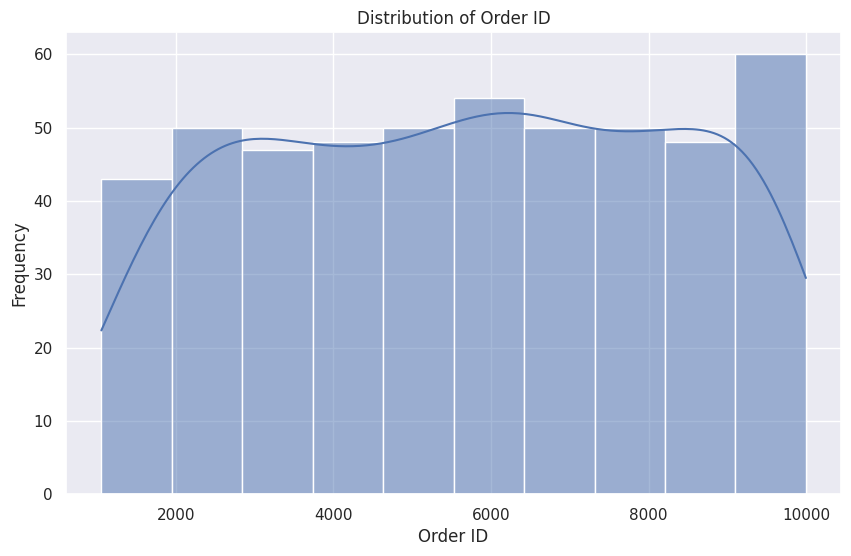

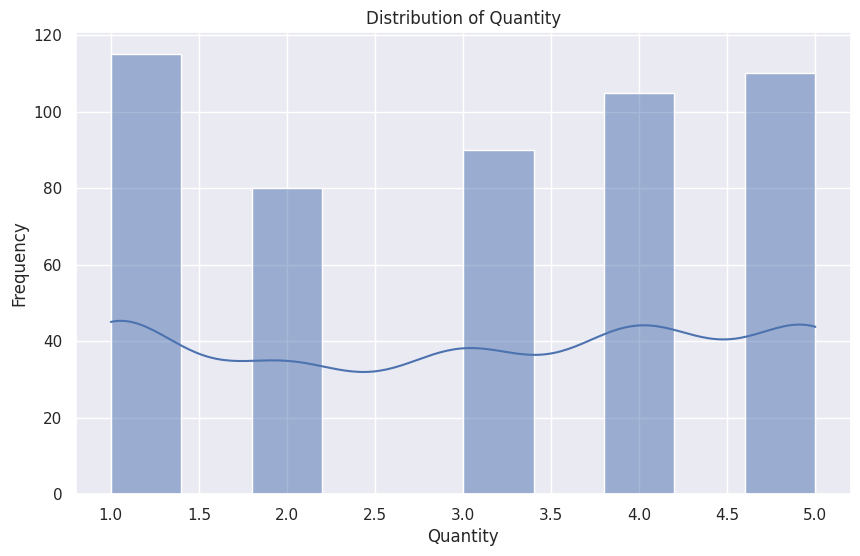

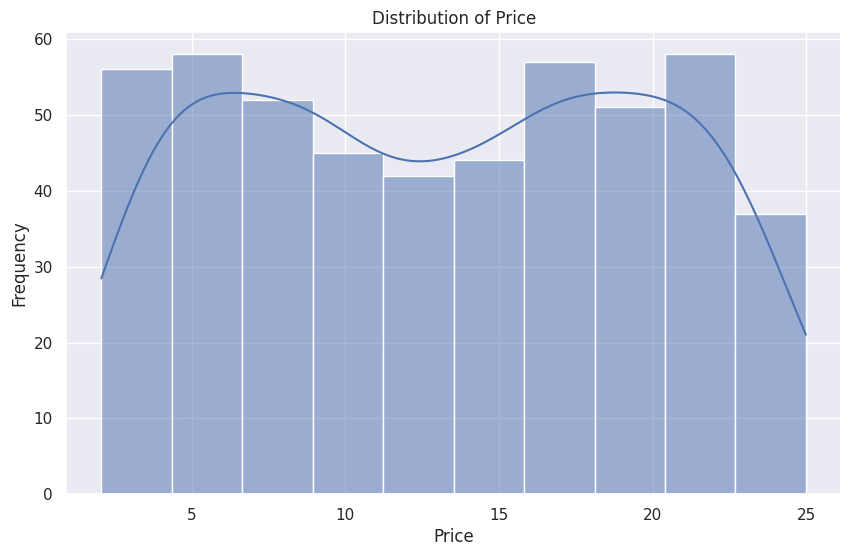

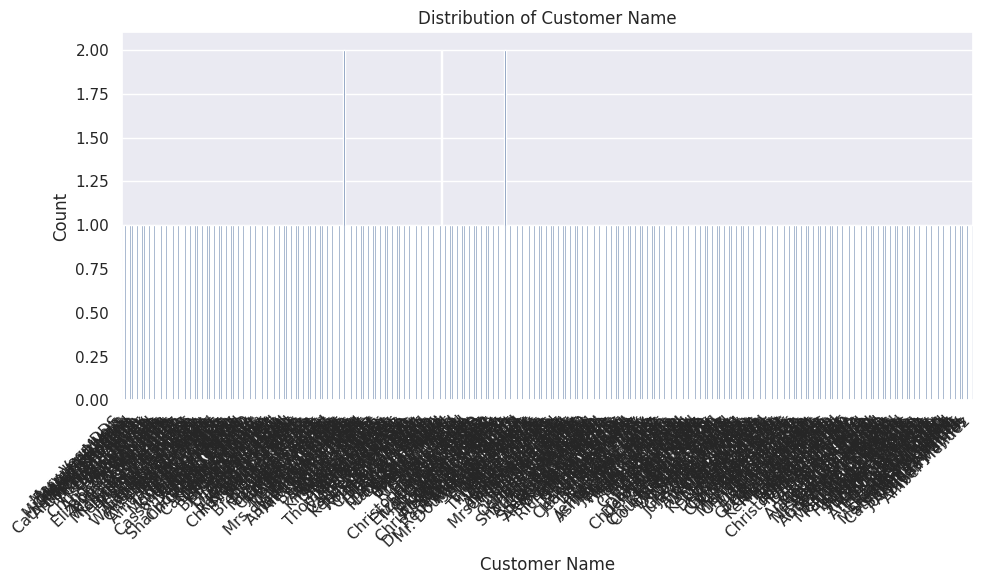

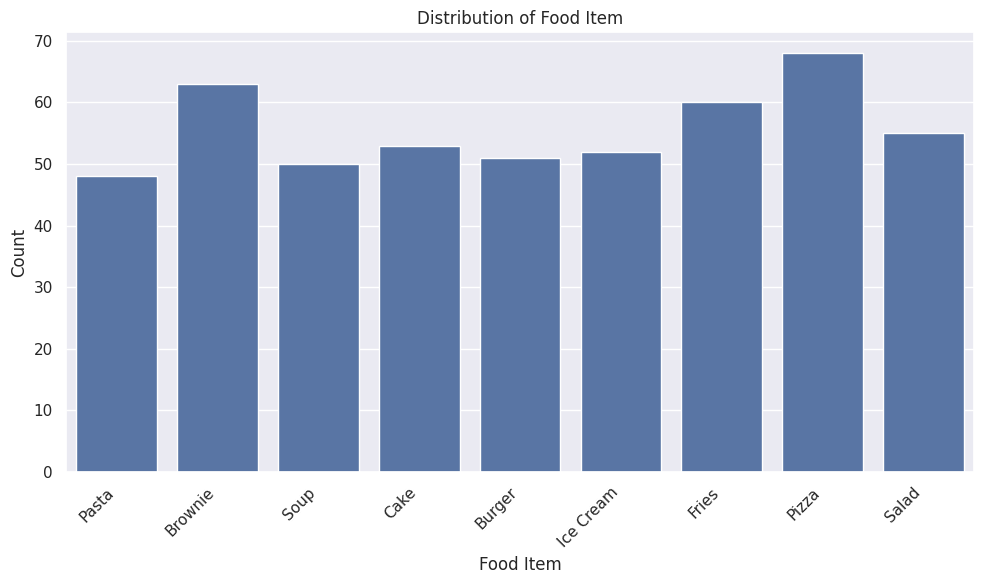

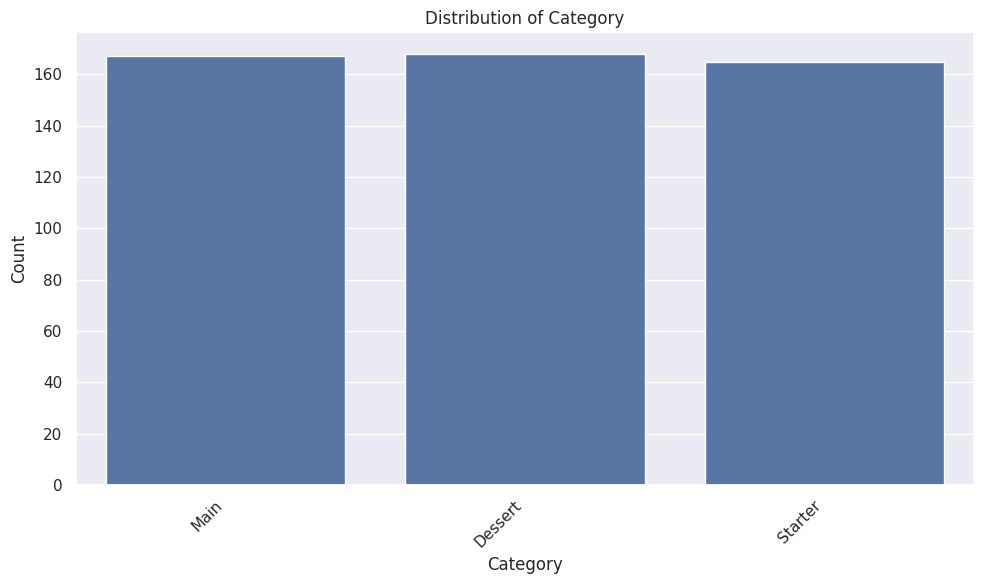

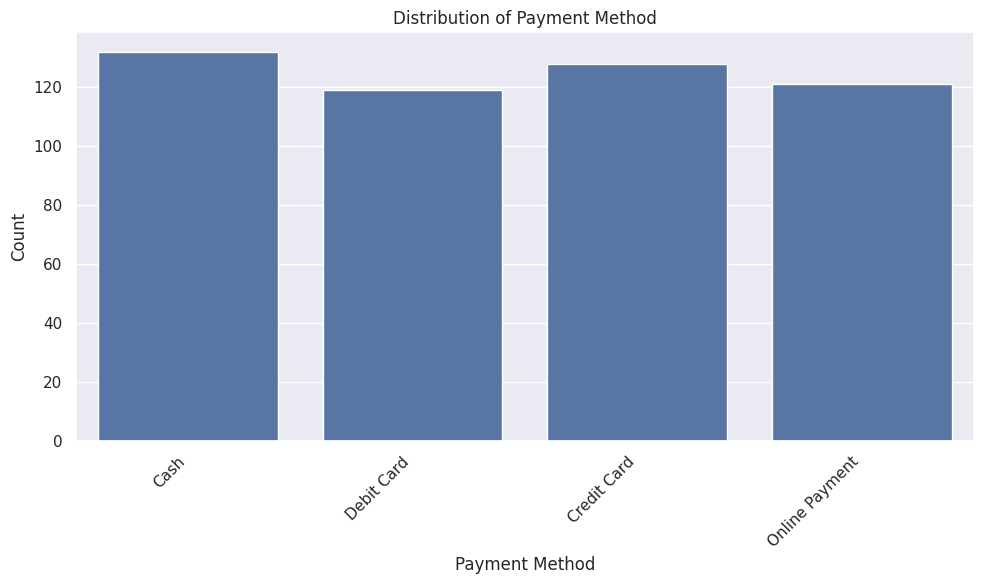

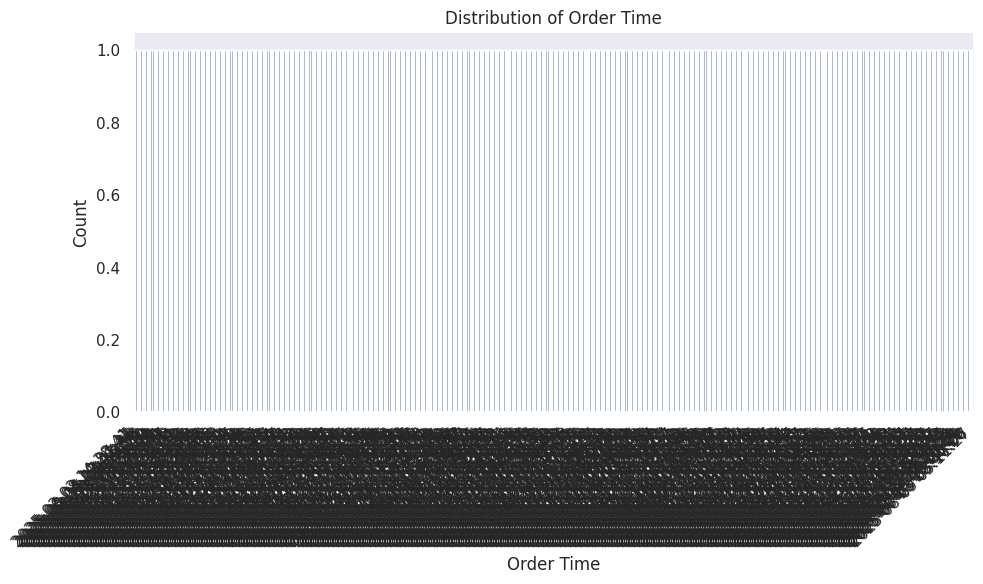

Value counts for Customer Name:
Customer Name
Michael Smith            2
Jonathan Turner          2
Christopher Rodriguez    2
Ashley Wilson            1
Stacy Wagner             1
                        ..
David Barrett            1
Nathan Harris            1
Mark Winters             1
Steven Larson            1
Kenneth Coleman          1
Name: count, Length: 497, dtype: int64

Value counts for Food Item:
Food Item
Pizza        68
Brownie      63
Fries        60
Salad        55
Cake         53
Ice Cream    52
Burger       51
Soup         50
Pasta        48
Name: count, dtype: int64

Value counts for Category:
Category
Dessert    168
Main       167
Starter    165
Name: count, dtype: int64

Value counts for Payment Method:
Payment Method
Cash              132
Credit Card       128
Online Payment    121
Debit Card        119
Name: count, dtype: int64

Value counts for Order Time:
Order Time
2025-08-09 05:11:27    1
2025-02-02 14:28:41    1
2025-06-08 10:57:47    1
2025-03-04 07:41:41   

In [18]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

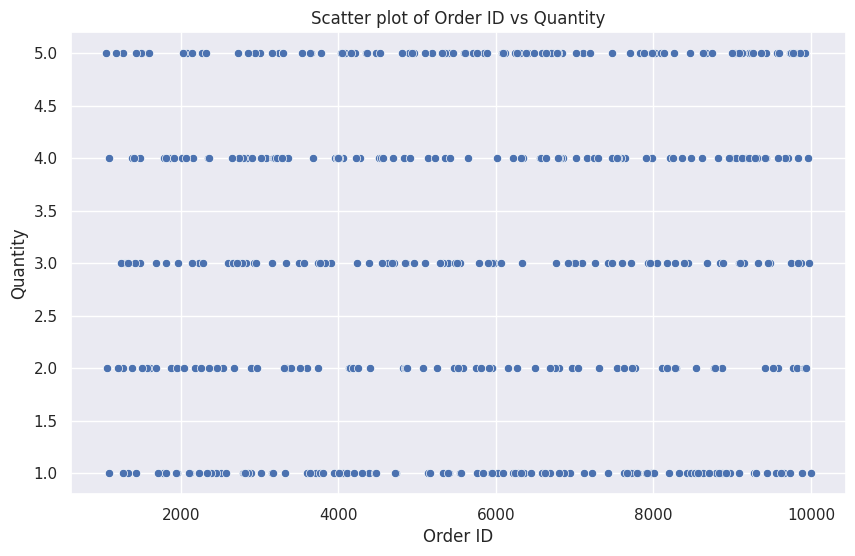

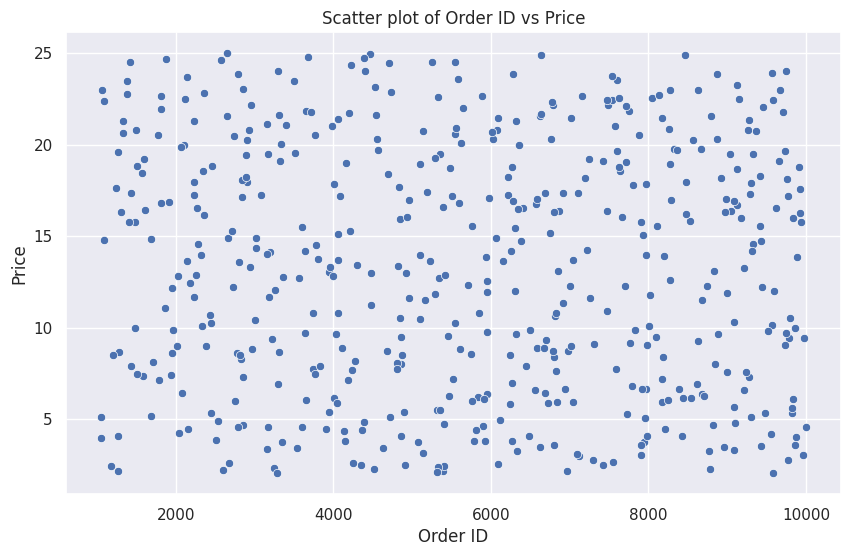

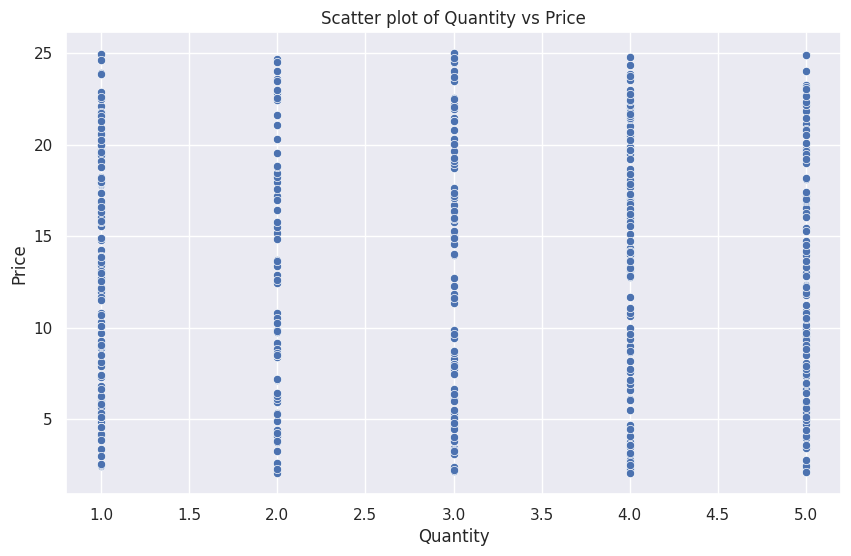

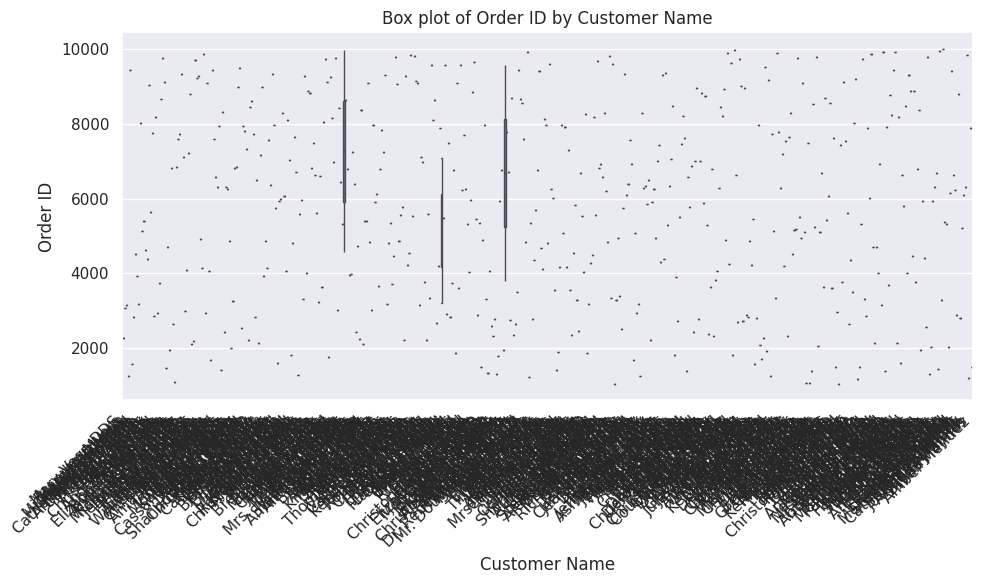

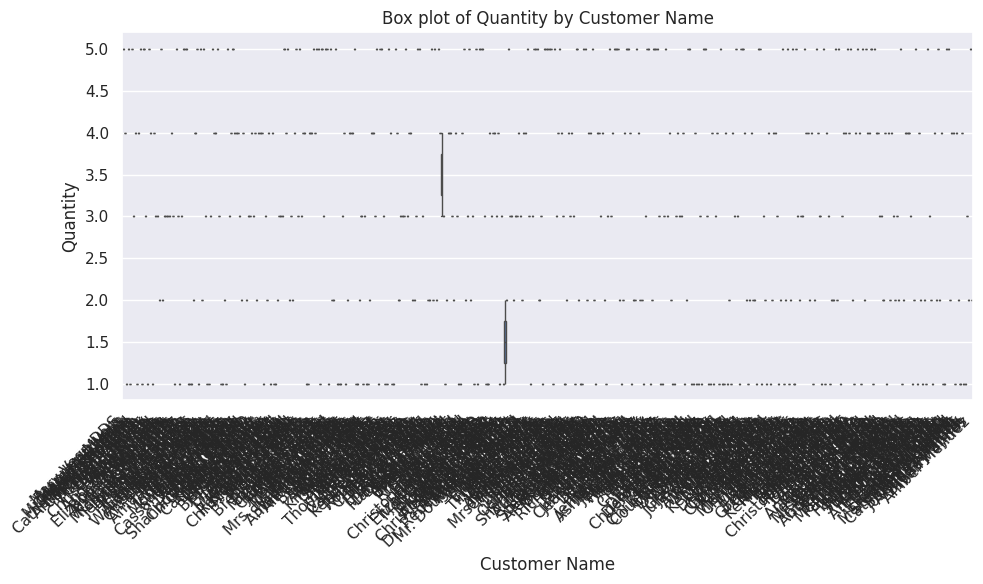

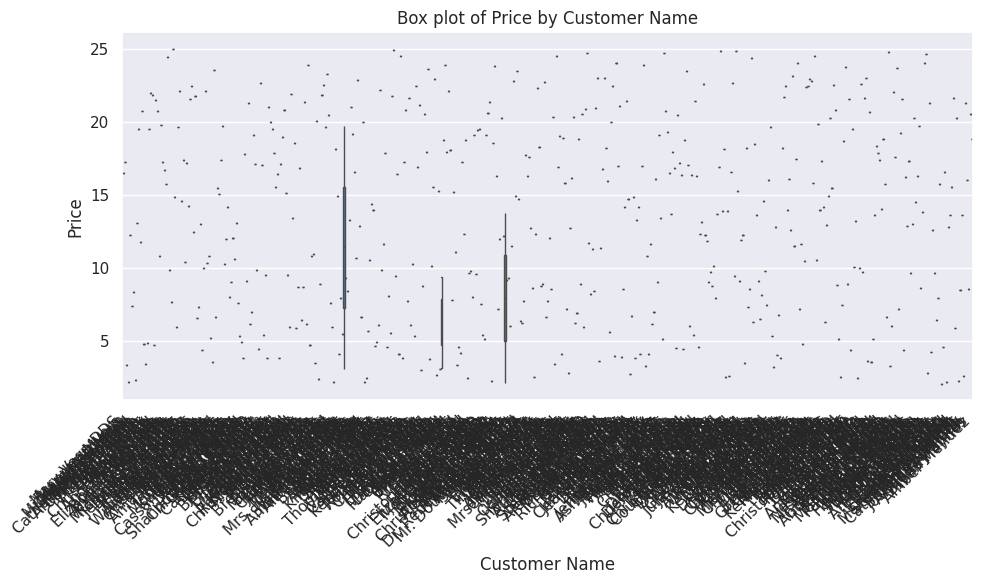

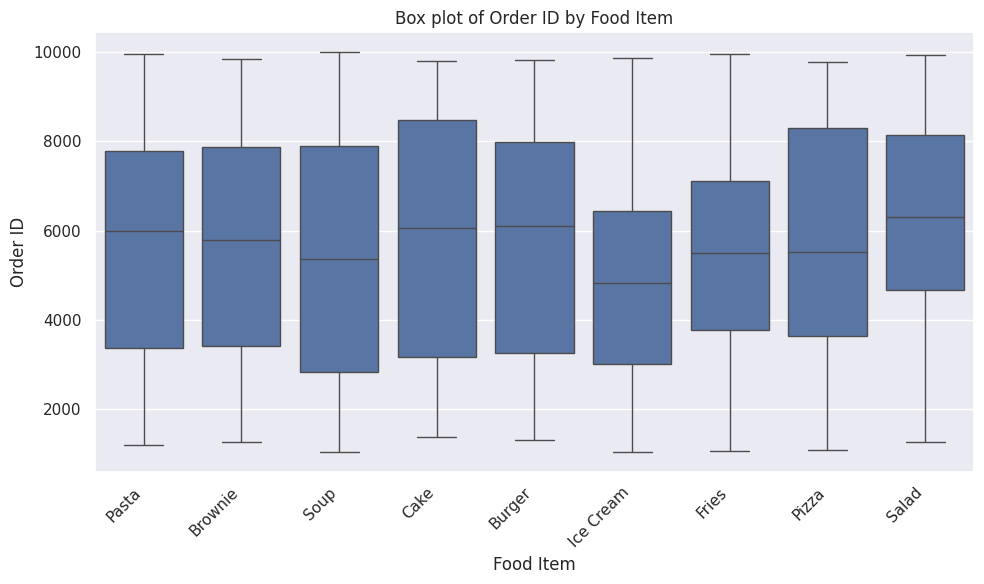

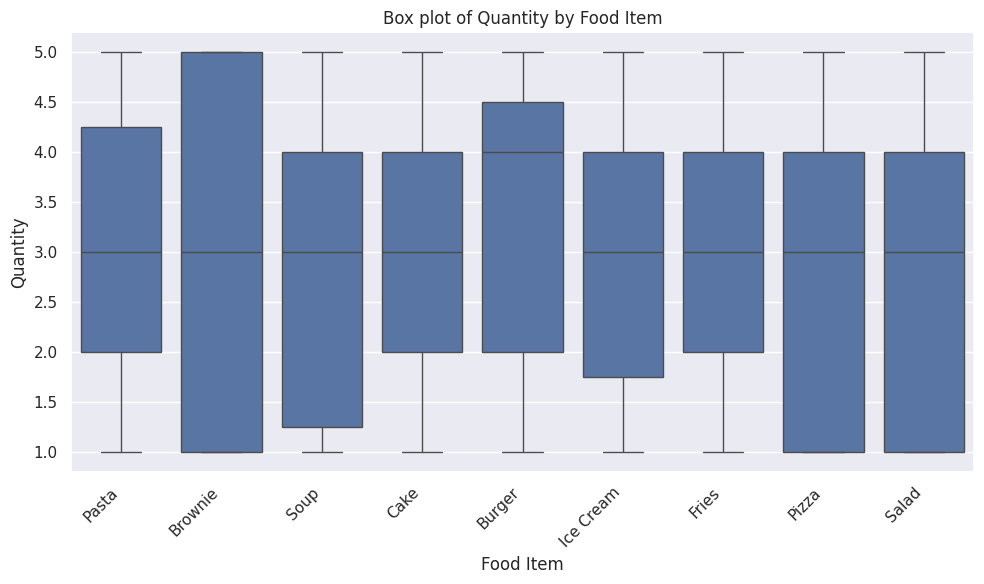

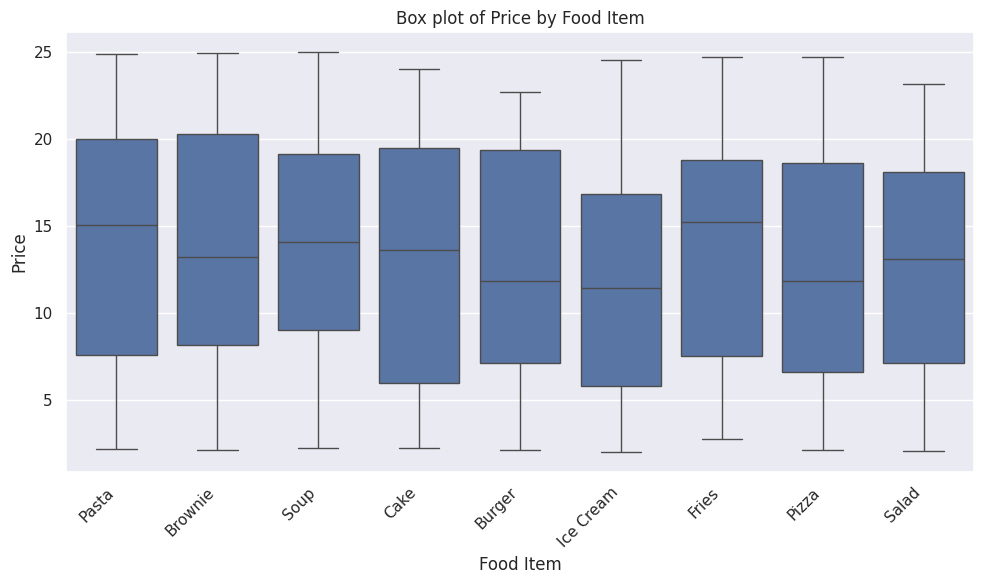

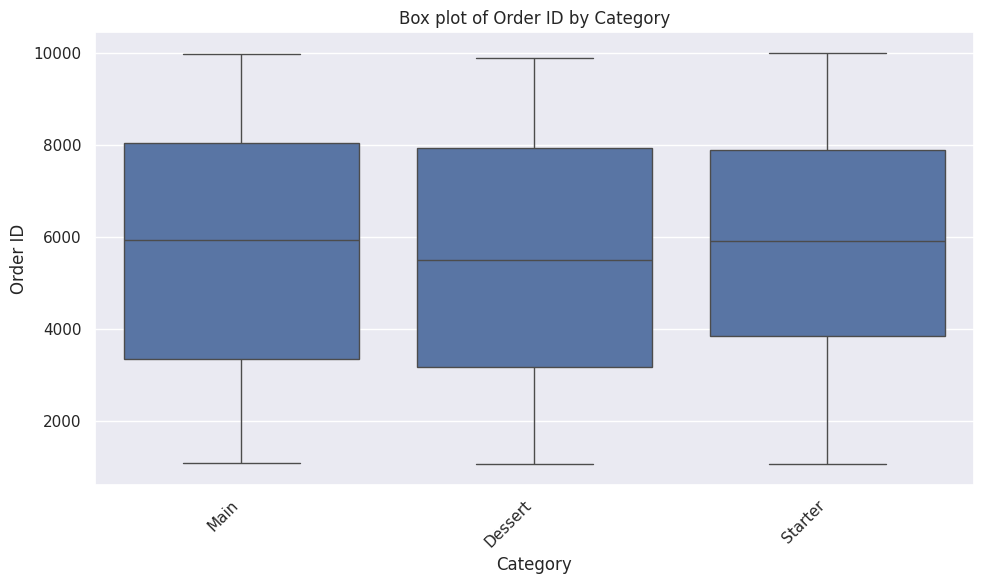

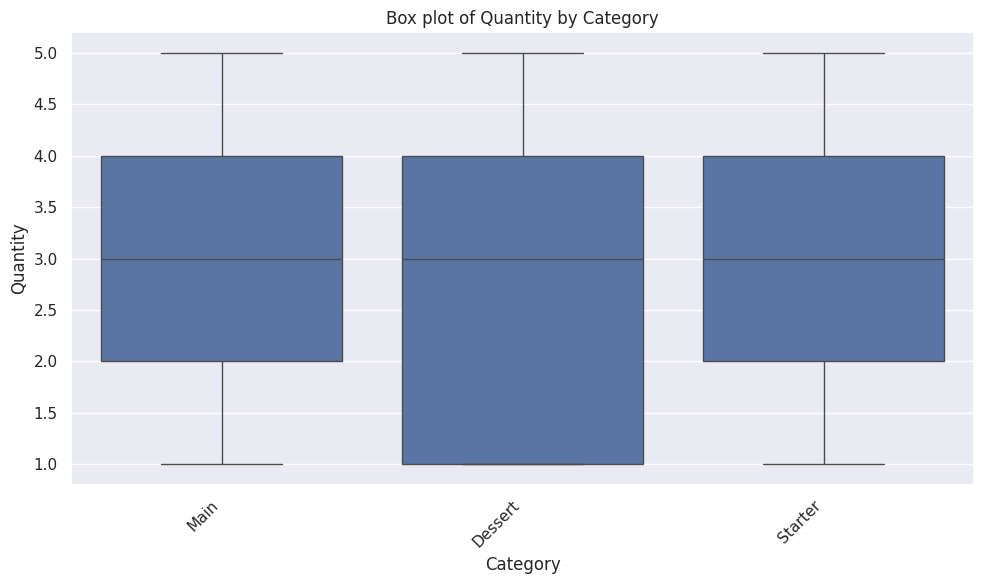

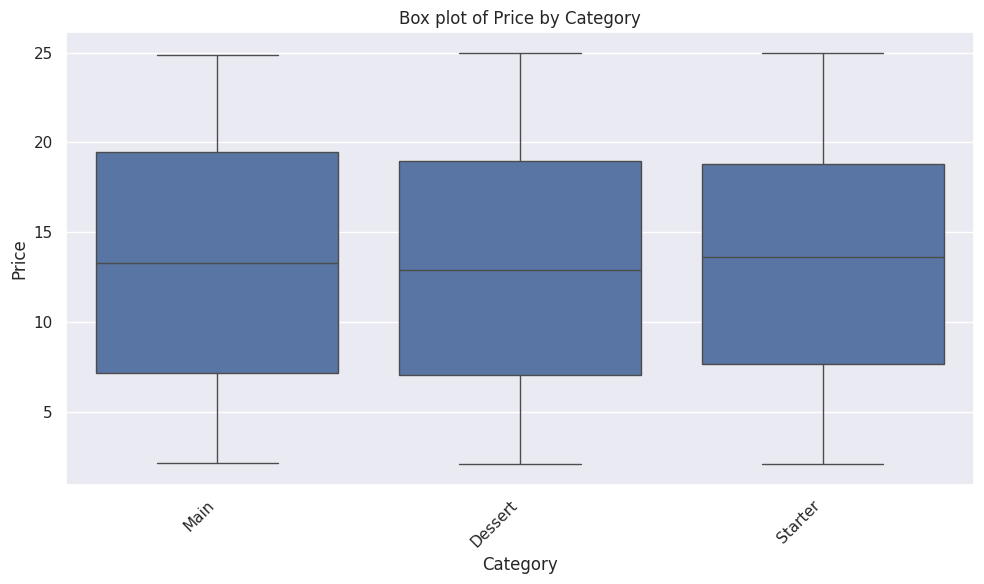

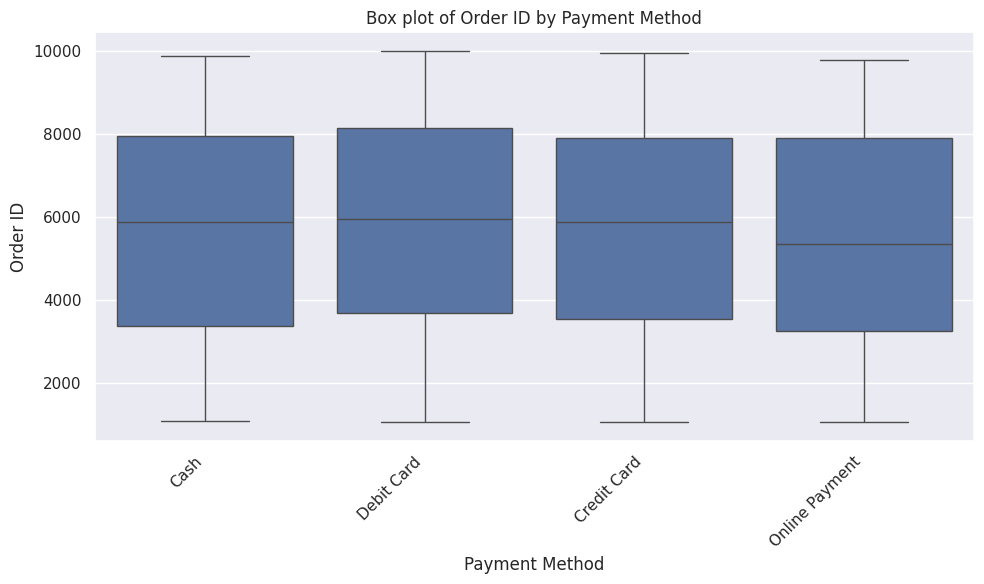

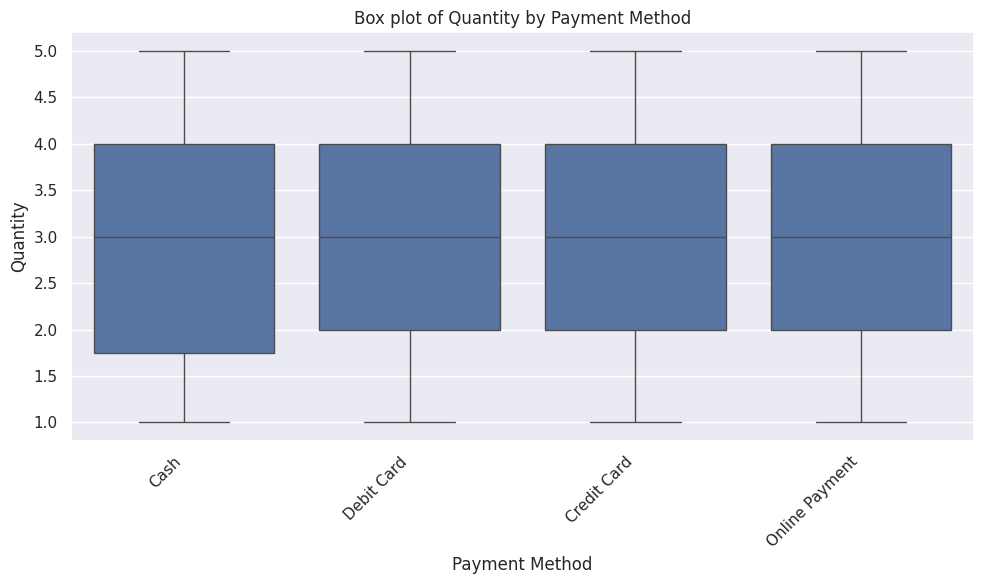

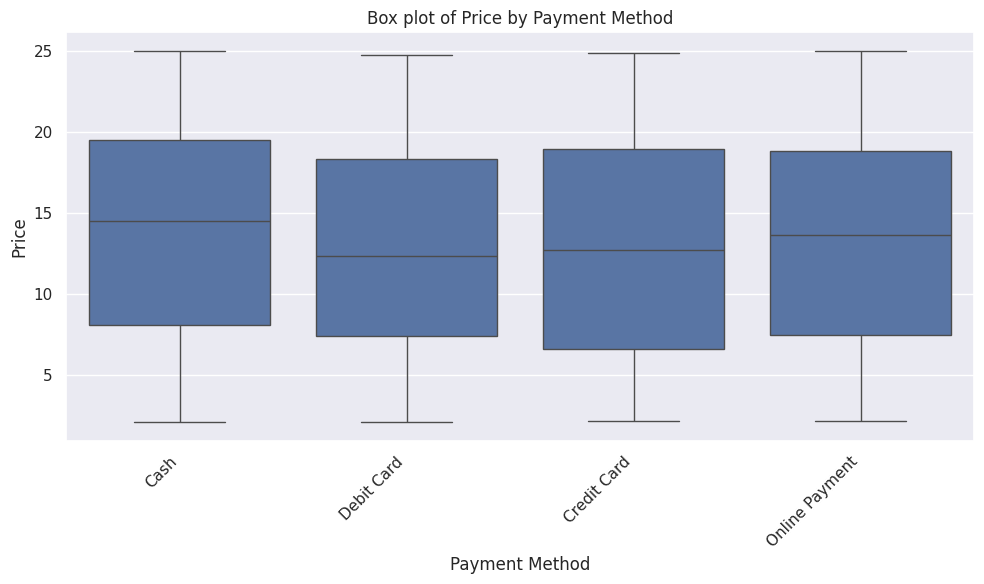

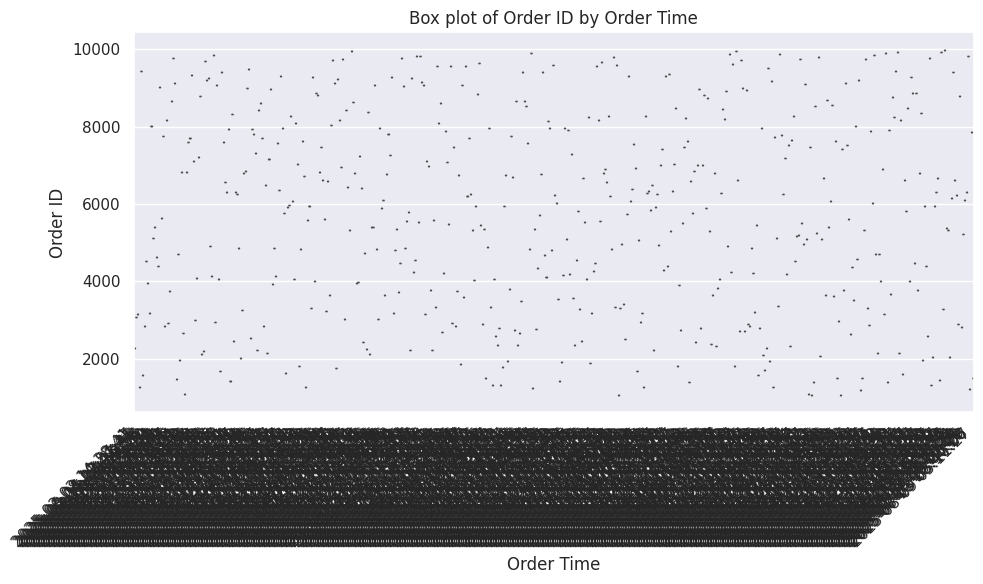

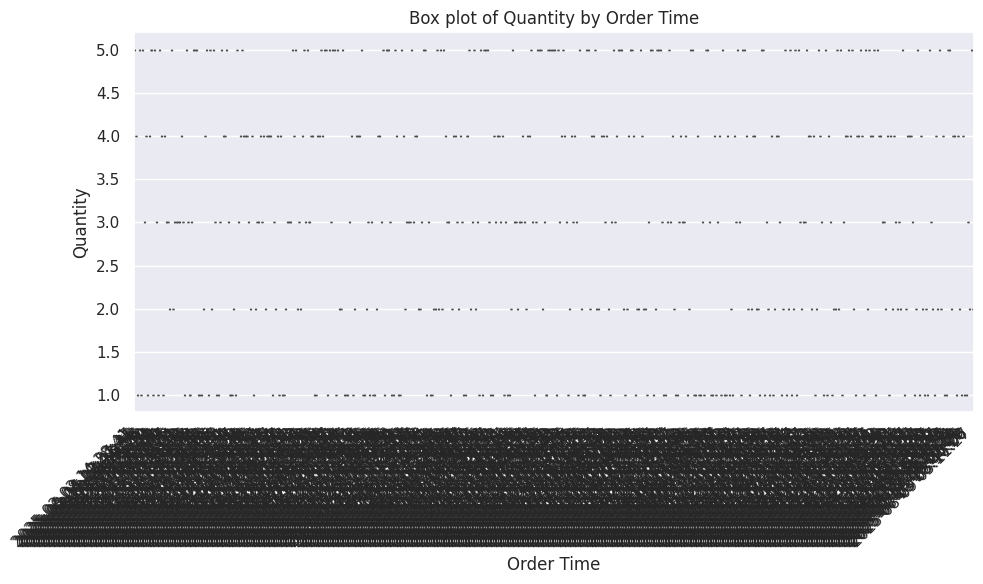

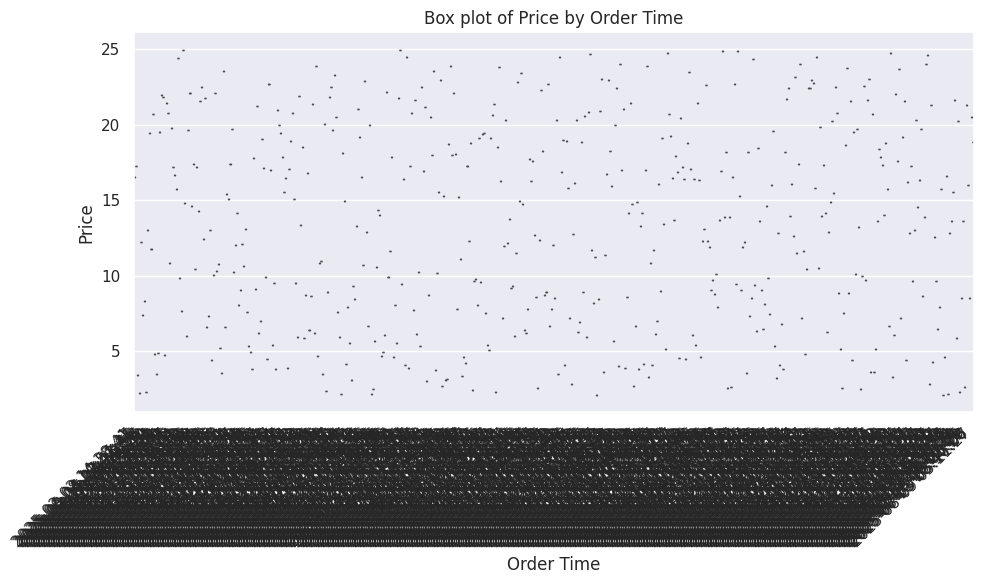

In [19]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Multivariate Analysis

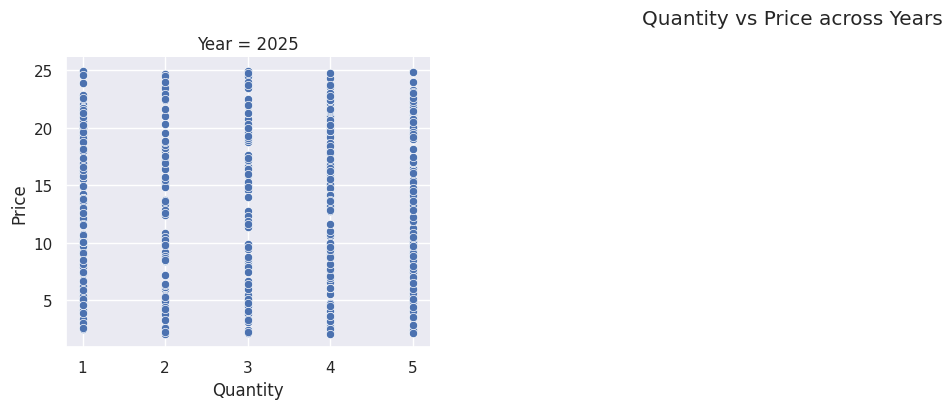

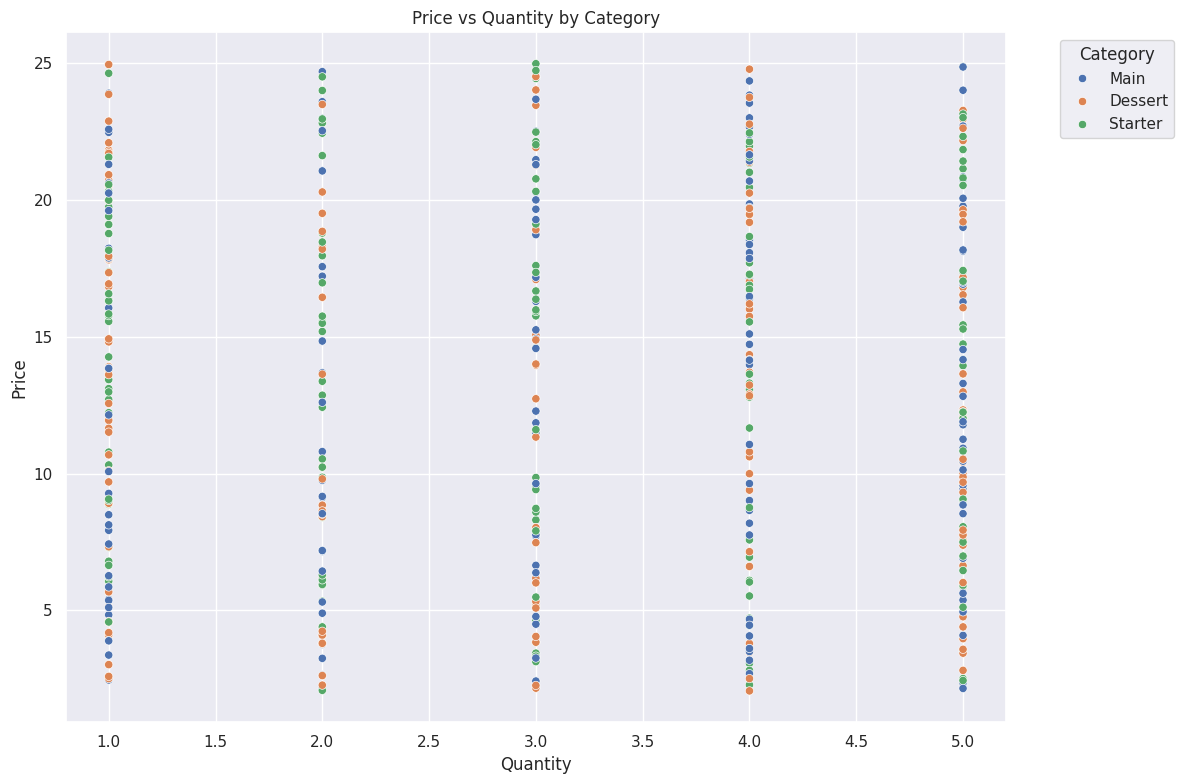

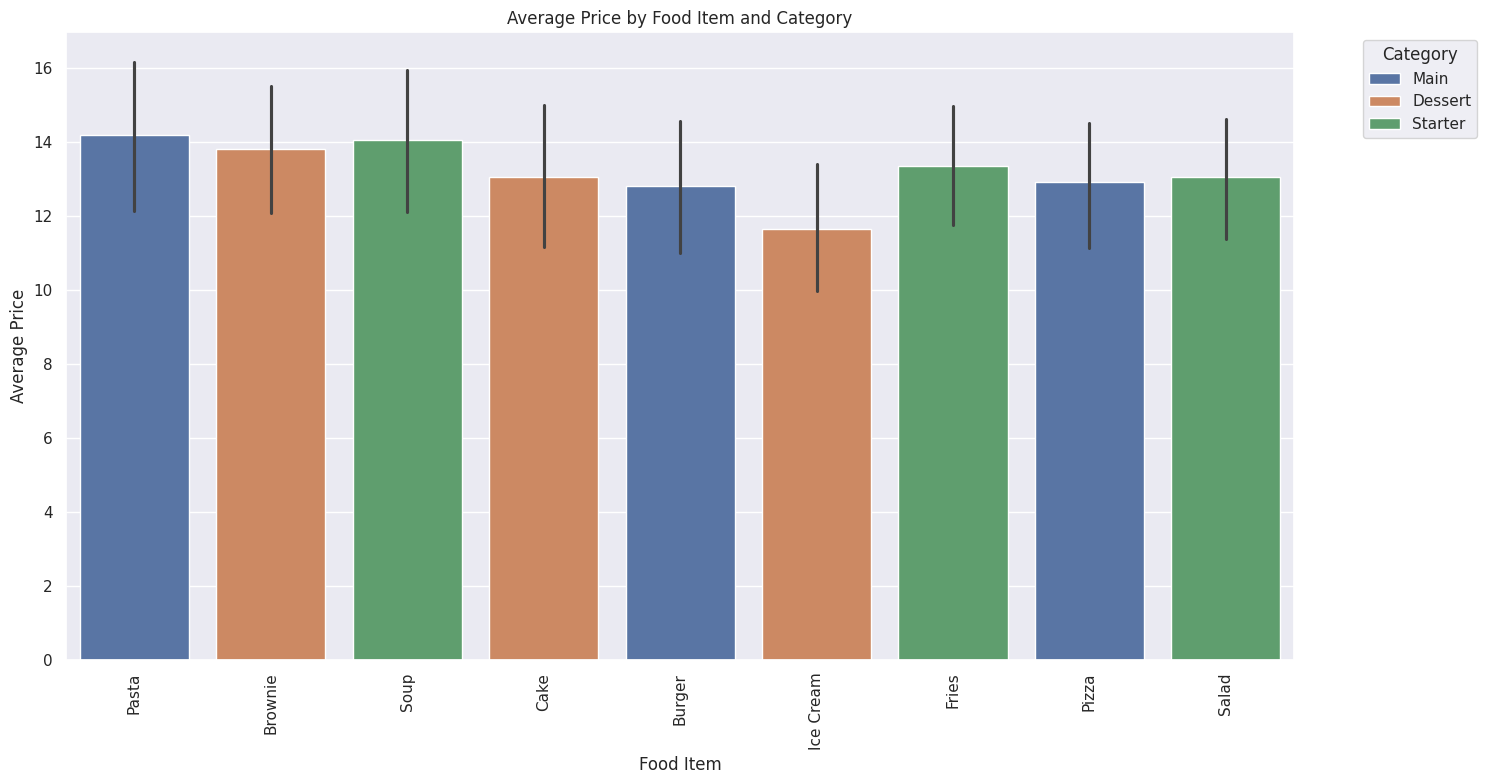

In [22]:
# Convert 'Order Time' to datetime objects
df['Order Time'] = pd.to_datetime(df['Order Time'])

# Extract the year from 'Order Time'
df['Year'] = df['Order Time'].dt.year

# Relationship between Quantity, Price, and Year
g = sns.FacetGrid(df, col="Year", col_wrap=4, height=4)
g.map(sns.scatterplot, "Quantity", "Price")
plt.suptitle('Quantity vs Price across Years', y=1.02)
plt.show()

# Relationship between Price, Quantity, and Category
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="Quantity", y="Price", hue="Category")
plt.title('Price vs Quantity by Category')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Exploring relationships between a numerical variable and two categorical variables
# Price by Food Item and Category (using a bar plot)
plt.figure(figsize=(15, 8))
sns.barplot(data=df, x="Food Item", y="Price", hue="Category")
plt.title('Average Price by Food Item and Category')
plt.xlabel('Food Item')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

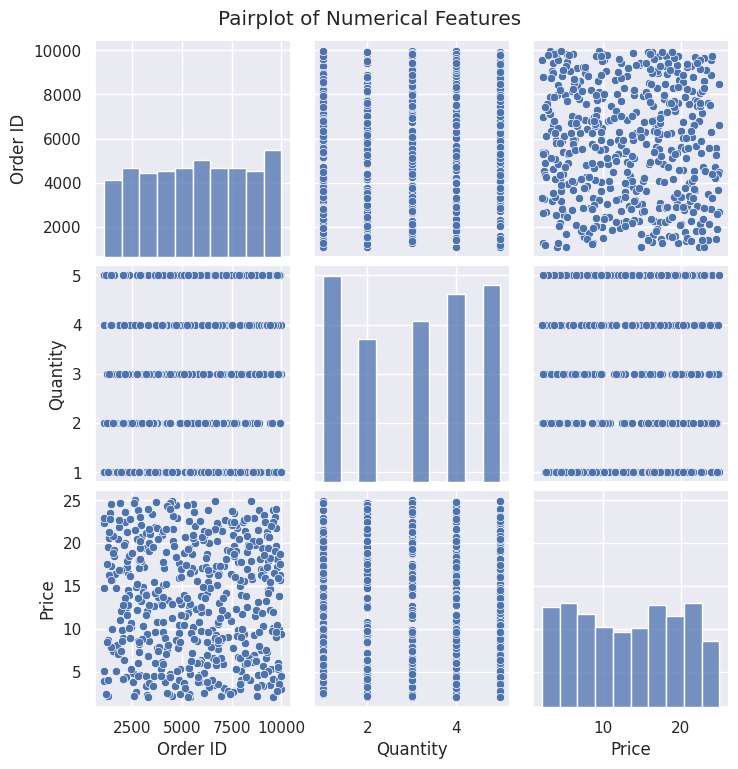

In [21]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

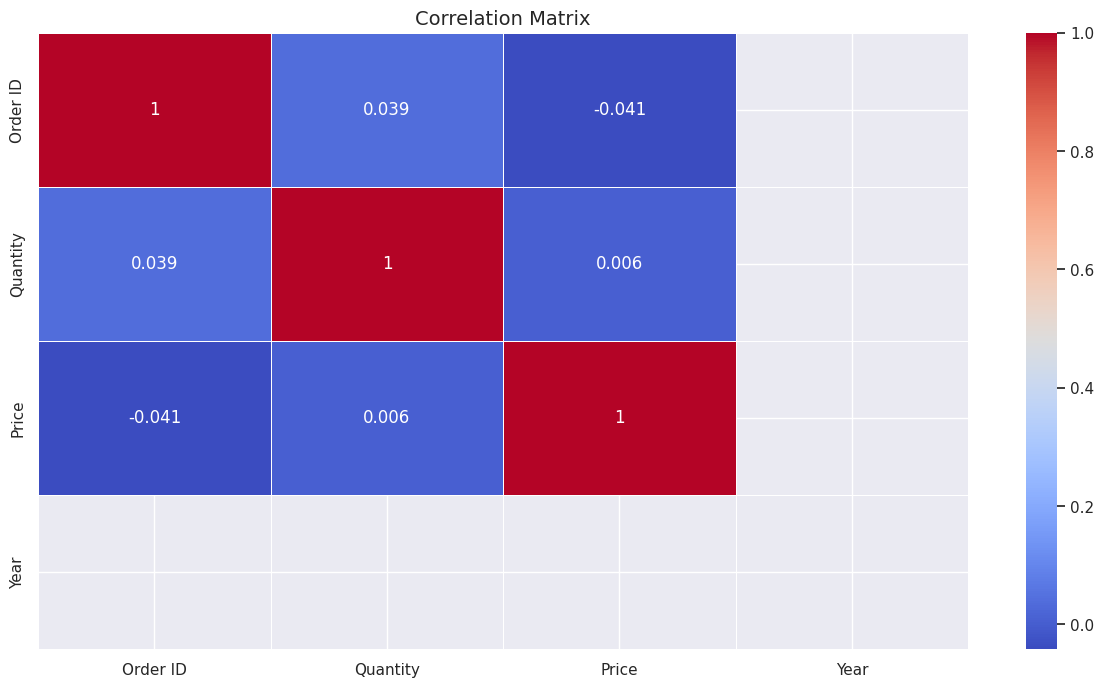

In [23]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you